<h1>Secciones Obsoletas — MammoVLM V2</h1>
<p>Celdas extraídas de <code>main.ipynb</code> durante la limpieza de junio 2026.</p>
<p>Se conservan aquí por referencia; <strong>no forman parte del flujo activo (exp08)</strong>.</p>
<hr/>
<h2>Razones de deprecación por sección</h2>
<ul>
<li><b>Sección 4 (Área 1 — demos sintéticos)</b>: Demos de CoherenceValidator, CalibrationAnalyzer, ConsistencyAnalyzer y AlignmentMetricsCollector con datos sintéticos. La sección 12 evalúa coherencia sobre datos reales de forma autónoma.</li>
<li><b>Sección 5.1 (Esquema de hallazgos)</b>: Esquema de 8 hallazgos morfológicos (FindingsSchema). El modelo final (exp08) no predice hallazgos morfológicos por seguridad clínica; solo predice BI-RADS y densidad.</li>
<li><b>Sección 6 (Área 3 — métricas demo)</b>: Evaluación clínica con datos sintéticos. La evaluación real sobre el test set de VinDr vive en la sección 9.7 del notebook activo.</li>
<li><b>Sección 7 (Área 4 — CDD-CESM)</b>: Parser de reportes CDD-CESM y evaluación de hallazgos morfológicos. Decisión: no se usa CDD-CESM ni se evalúan hallazgos morfológicos en exp08.</li>
<li><b>Sección 8 (Validación de datasets)</b>: Validadores de los 5 datasets originales (VinDr, INbreast, DMID, CDD-CESM, CBIS-DDSM). El modelo final solo usa VinDr-Mammo.</li>
</ul>


<h2 id='area1'>4. Area 1: Metricas de Alineacion LLM-Vision</h2>
<p>Validacion de coherencia, calibracion y consistencia del modelo, ahora integrada con el lexico oficial ACR BI-RADS.</p>

<h3>4.1 Vocabulario medico BI-RADS</h3>

In [59]:
## Explorar el lexico BI-RADS cargado
print_section('LEXICO BI-RADS OFICIAL', width=70)

lexicon = birads_lexicon
all_descriptors = lexicon.get_all_descriptors()
print(f'Total descriptores cargados: {len(all_descriptors)}')
print()

## Mostrar descriptores por categoria
categories = defaultdict(list)
for d in all_descriptors:
    categories[d.category].append(d.canonical)

for cat, descriptors in sorted(categories.items()):
    print(f'  {cat:25s} ({len(descriptors):2d}): {descriptors[0]}')
    for desc in descriptors[1:]:
        print(f'  {"":25s}       {desc}')
    print()

## Mostrar categorias de evaluacion
print('Categorias de evaluacion BI-RADS:')
for level, info in lexicon.assessment_categories.items():
    print(f'  BI-RADS {level}: {info["name"]:35s} -> {info["recommendation"]}')

                        LEXICO BI-RADS OFICIAL                        
Total descriptores cargados: 43

  associated                ( 5): skin retraction
                                  nipple retraction
                                  skin thickening
                                  trabecular thickening
                                  axillary adenopathy

  asymmetry                 ( 3): asymmetry
                                  focal asymmetry
                                  global asymmetry

  calc_distribution         ( 5): diffuse
                                  regional
                                  grouped
                                  linear
                                  segmental

  calc_morphology           (13): amorphous
                                  coarse heterogeneous
                                  fine pleomorphic
                                  fine linear
                                  skin calcifications
                        

<h3>4.2 CoherenceValidator con lexico BI-RADS</h3>

In [60]:
## Crear validador con vocabulario medico integrado
validator = CoherenceValidator(use_medical_vocabulary=True)

## Caso 1: Informe bien redactado con terminologia BI-RADS correcta
record_good = PredictionRecord(
    image_id='img_001_good_report',
    birads_pred=5,
    birads_confidence=0.94,
    findings_pred=['spiculated mass', 'architectural distortion'],
    explanation_text=(
        'Se identifica una masa de contornos espiculados (spiculated) de 2.3 cm '
        'en el cuadrante superoexterno de la mama derecha, con margenes irregulares '
        'y densidad alta (high density). Se observa distorsion arquitectural '
        '(architectural distortion) asociada con retraccion cutanea (skin retraction). '
        'El tejido mamario es heterogeneamente denso (heterogeneously dense). '
        'Hallazgo altamente sugestivo de malignidad. '
        'Se recomienda biopsia inmediata y evaluacion histopatologica urgente.'
    ),
    ground_truth_birads=5,
)

metrics_good = validator.validate_record(record_good)

print_section('Caso 1: Informe con terminologia BI-RADS correcta', width=70)
print(f'BI-RADS predicho: {record_good.birads_pred}')
print(f'Confianza: {record_good.birads_confidence:.4f}')
print()
print('Metricas de coherencia:')
for key, value in metrics_good.items():
    print(f'  {key:35s} {value:.4f}')
print()

          Caso 1: Informe con terminologia BI-RADS correcta           
BI-RADS predicho: 5
Confianza: 0.9400

Metricas de coherencia:
  birads_mention_coherence            1.0000
  findings_support_coherence          1.0000
  explanation_completeness            1.0000
  terminology_adherence               1.0000
  recommendation_coherence            1.0000
  overall_coherence                   1.0000



In [61]:
## Caso 2: Informe pobre sin terminologia BI-RADS
record_poor = PredictionRecord(
    image_id='img_002_poor_report',
    birads_pred=4,
    birads_confidence=0.72,
    findings_pred=['suspicious lesion'],
    explanation_text=(
        'Se observa algo sospechoso en la mama. '
        'Podria ser maligno. Se recomienda hacer algo.'
    ),
    ground_truth_birads=4,
)

metrics_poor = validator.validate_record(record_poor)

print_section('Caso 2: Informe POBRE sin terminologia BI-RADS', width=70)
print(f'BI-RADS predicho: {record_poor.birads_pred}')
print(f'Confianza: {record_poor.birads_confidence:.4f}')
print()
print('Metricas de coherencia:')
for key, value in metrics_poor.items():
    print(f'  {key:35s} {value:.4f}')
print()

## Comparacion
print_section('COMPARACION', width=70)
print(f'{"Metrica":35s} {"Bueno":>8s} {"Pobre":>8s} {"Diferencia":>10s}')
print('-' * 65)
for key in metrics_good:
    diff = metrics_good[key] - metrics_poor[key]
    print(f'{key:35s} {metrics_good[key]:8.4f} {metrics_poor[key]:8.4f} {diff:+10.4f}')

            Caso 2: Informe POBRE sin terminologia BI-RADS            
BI-RADS predicho: 4
Confianza: 0.7200

Metricas de coherencia:
  birads_mention_coherence            0.6000
  findings_support_coherence          0.0000
  explanation_completeness            0.5000
  terminology_adherence               0.0000
  recommendation_coherence            0.0000
  overall_coherence                   0.2250

                             COMPARACION                              
Metrica                                Bueno    Pobre Diferencia
-----------------------------------------------------------------
birads_mention_coherence              1.0000   0.6000    +0.4000
findings_support_coherence            1.0000   0.0000    +1.0000
explanation_completeness              1.0000   0.5000    +0.5000
terminology_adherence                 1.0000   0.0000    +1.0000
recommendation_coherence              1.0000   0.0000    +1.0000
overall_coherence                     1.0000   0.2250    +0.7750


<h3>4.3 CalibrationAnalyzer</h3>

In [62]:
## Analizador de calibracion
calibration_analyzer = CalibrationAnalyzer(n_bins=5)

## Datos sinteticos de prueba
np.random.seed(42)
n_samples = 200

predictions = np.random.randint(0, 6, n_samples)
ground_truth = predictions.copy()
error_indices = np.random.choice(n_samples, int(0.2 * n_samples), replace=False)
ground_truth[error_indices] = np.random.randint(0, 6, len(error_indices))

confidences = np.zeros(n_samples)
for i in range(n_samples):
    if predictions[i] == ground_truth[i]:
        confidences[i] = np.random.uniform(0.75, 1.0)
    else:
        confidences[i] = np.random.uniform(0.2, 0.6)

cal_metrics = calibration_analyzer.compute_calibration_metrics(
    predictions, confidences, ground_truth
)

print_section('METRICAS DE CALIBRACION', width=70)
print(f'Muestras evaluadas: {n_samples}')
print()
for key, value in cal_metrics.items():
    print(f'  {key:30s} {value:.4f}')
print()
if cal_metrics['ece'] <= 0.15:
    print(f'Interpretacion: ECE {cal_metrics["ece"]:.4f} - BIEN CALIBRADO')
else:
    print(f'Interpretacion: ECE {cal_metrics["ece"]:.4f} - NECESITA MEJORA')

                       METRICAS DE CALIBRACION                        
Muestras evaluadas: 200

  accuracy                       0.8650
  brier_score                    0.1641
  ece                            0.1716
  mce                            0.5053
  nll                            0.4212

Interpretacion: ECE 0.1716 - NECESITA MEJORA


<h3>4.4 ConsistencyAnalyzer</h3>

In [63]:
## Analizador de consistencia
consistency_analyzer = ConsistencyAnalyzer()

## Imagen 1: predicciones consistentes
consistency_analyzer.record_prediction('img_A', birads_pred=3, confidence=0.85)
consistency_analyzer.record_prediction('img_A', birads_pred=3, confidence=0.83)
consistency_analyzer.record_prediction('img_A', birads_pred=3, confidence=0.87)

## Imagen 2: predicciones inconsistentes
consistency_analyzer.record_prediction('img_B', birads_pred=2, confidence=0.65)
consistency_analyzer.record_prediction('img_B', birads_pred=4, confidence=0.68)
consistency_analyzer.record_prediction('img_B', birads_pred=2, confidence=0.62)

## Imagen 3: alta consistencia
consistency_analyzer.record_prediction('img_C', birads_pred=5, confidence=0.90)
consistency_analyzer.record_prediction('img_C', birads_pred=5, confidence=0.88)
consistency_analyzer.record_prediction('img_C', birads_pred=5, confidence=0.91)

con_metrics = consistency_analyzer.compute_consistency_metrics()

print_section('METRICAS DE CONSISTENCIA', width=70)
if con_metrics.get('consistency_available'):
    print(f'Imagenes evaluadas:          {con_metrics["num_images_evaluated"]}')
    print(f'Acuerdo BI-RADS:             {con_metrics["birads_agreement_rate"]*100:.1f}%')
    print(f'Desv. estandar confianza:    {con_metrics["confidence_std_mean"]:.4f} (media)')
    print(f'                             {con_metrics["confidence_std_max"]:.4f} (maxima)')
else:
    print('Consistencia no evaluable')

                       METRICAS DE CONSISTENCIA                       
Imagenes evaluadas:          3
Acuerdo BI-RADS:             66.7%
Desv. estandar confianza:    0.0178 (media)
                             0.0245 (maxima)


<h3>4.5 Colector Integrado de Area 1</h3>

In [64]:
## Crear colector integrado
area1_collector = AlignmentMetricsCollector(n_calibration_bins=5)

## Generar registros sinteticos con terminologia BI-RADS variable
np.random.seed(42)
n_test = 50

## Templates de explicaciones con diferente calidad terminologica
templates = {
    'high_quality': {
        'benign': (
            'Estudio mamografico negativo. Tejido mamario de densidad '
            'scattered fibroglandular (ACR b). Sin hallazgos patologicos. '
            'No se identifican masas, calcificaciones sospechosas ni '
            'distorsion arquitectural. Estudio normal. '
            'Recomendacion: screening rutinario anual.'
        ),
        'suspicious': (
            'Se identifica masa de contornos espiculados (spiculated) de '
            'margenes irregulares con densidad alta (high density) en mama '
            'derecha. Distorsion arquitectural (architectural distortion) '
            'asociada. Tejido heterogeneously dense. Hallazgo altamente '
            'sugestivo de malignidad. Biopsia inmediata recomendada.'
        ),
    },
    'low_quality': {
        'benign': 'Todo se ve normal. No hay problema.',
        'suspicious': 'Hay algo sospechoso. Deberia revisarse.',
    },
}

for i in range(n_test):
    birads = np.random.randint(0, 6)
    confidence = np.random.uniform(0.6, 0.99)
    
    ## 70% buena calidad, 30% baja calidad
    quality = 'high_quality' if np.random.random() > 0.3 else 'low_quality'
    category = 'benign' if birads <= 2 else 'suspicious'
    explanation = templates[quality][category]
    
    if birads <= 2:
        findings = ['normal']
    elif birads == 3:
        findings = ['probably benign']
    else:
        findings = ['spiculated mass', 'architectural distortion']
    
    record = PredictionRecord(
        image_id=f'img_{i:03d}',
        birads_pred=birads,
        birads_confidence=confidence,
        findings_pred=findings,
        explanation_text=explanation,
        ground_truth_birads=birads,
    )
    area1_collector.add_prediction(record)

print(f'Procesados {n_test} registros de prediccion')

Procesados 50 registros de prediccion


In [65]:
## Generar reporte final de Area 1
area1_report = area1_collector.compute_final_report()
print(area1_collector.generate_summary())

## Guardar reporte
report_path = RESULTS_DIR / f'area1_alignment_{get_timestamp()}.json'
save_json(area1_report, report_path)
print(f'Reporte guardado: {report_path.name}')

AREA 1: METRICAS DE ALINEACION LLM-VISION

COHERENCIA EXPLICACION-PREDICCION
----------------------------------------------------------------------
  Coherencia promedio:              0.4919
  Desviacion estandar:              0.3640
  Coherencia minima:                0.0000
  Coherencia maxima:                1.0000
  % con coherencia >= 0.75:         34.0%

CONSISTENCIA DE PREDICCIONES
----------------------------------------------------------------------
  (Requiere multiples predicciones por imagen)

Reporte guardado: area1_alignment_2026-06-02_00-47-09.json


<h3>4.6 Visualizaciones de Area 1</h3>

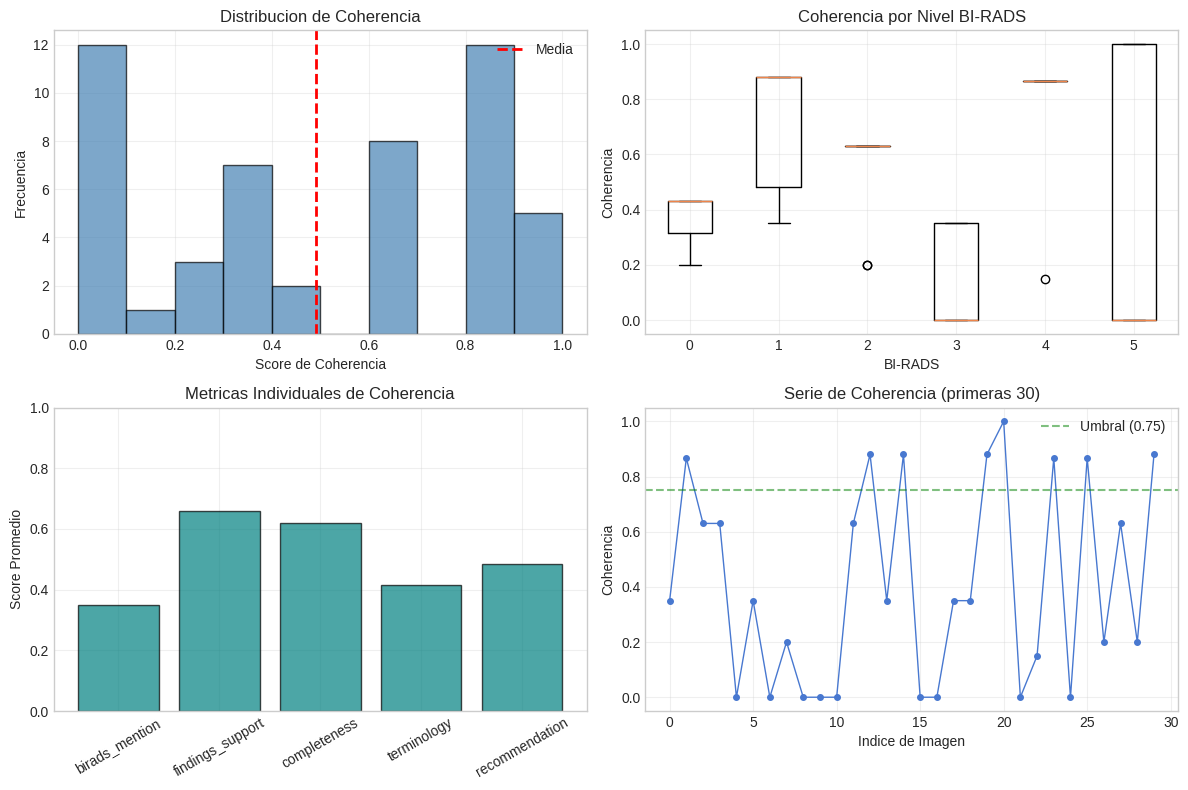

Grafica guardada: area1_coherence_analysis.png


In [66]:
## Graficas de Area 1
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

## 1. Histograma de coherencia
axes[0, 0].hist(area1_collector.coherence_scores, bins=10, alpha=0.7,
                color='steelblue', edgecolor='black')
axes[0, 0].axvline(np.mean(area1_collector.coherence_scores), color='red',
                   linestyle='--', linewidth=2, label='Media')
axes[0, 0].set_xlabel('Score de Coherencia')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribucion de Coherencia')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

## 2. Box plot por BI-RADS
birads_groups = defaultdict(list)
for img_id, metrics in area1_collector.all_metrics.items():
    birads = metrics['record'].birads_pred
    coherence = metrics['coherence']['overall_coherence']
    birads_groups[birads].append(coherence)

data_box = [birads_groups[b] for b in sorted(birads_groups.keys())]
axes[0, 1].boxplot(data_box, labels=sorted(birads_groups.keys()))
axes[0, 1].set_xlabel('BI-RADS')
axes[0, 1].set_ylabel('Coherencia')
axes[0, 1].set_title('Coherencia por Nivel BI-RADS')
axes[0, 1].grid(True, alpha=0.3)

## 3. Metricas individuales comparadas
metric_names = ['birads_mention', 'findings_support', 'completeness',
                'terminology', 'recommendation']
metric_keys = ['birads_mention_coherence', 'findings_support_coherence',
               'explanation_completeness', 'terminology_adherence',
               'recommendation_coherence']

metric_means = []
for key in metric_keys:
    values = [m['coherence'][key] for m in area1_collector.all_metrics.values()]
    metric_means.append(np.mean(values))

axes[1, 0].bar(metric_names, metric_means, color='teal', alpha=0.7, edgecolor='black')
axes[1, 0].set_ylabel('Score Promedio')
axes[1, 0].set_title('Metricas Individuales de Coherencia')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].tick_params(axis='x', rotation=30)
axes[1, 0].grid(True, alpha=0.3)

## 4. Serie temporal de coherencia
image_ids = list(area1_collector.all_metrics.keys())[:30]
coherences = [area1_collector.all_metrics[img]['coherence']['overall_coherence']
              for img in image_ids]
axes[1, 1].plot(coherences, marker='o', linestyle='-', linewidth=1, markersize=4)
axes[1, 1].axhline(0.75, color='green', linestyle='--', alpha=0.5, label='Umbral (0.75)')
axes[1, 1].set_xlabel('Indice de Imagen')
axes[1, 1].set_ylabel('Coherencia')
axes[1, 1].set_title('Serie de Coherencia (primeras 30)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'area1_coherence_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafica guardada: area1_coherence_analysis.png')

<h3>5.1 Esquema de hallazgos alineado a BI-RADS</h3>

In [67]:
## Explorar el esquema de hallazgos
print_section('ESQUEMA DE HALLAZGOS (alineado a BI-RADS)', width=70)
print(f'Total de slots (heads de clasificacion): {findings_schema.get_total_heads()}')
print()
print('Slots y sus valores posibles:')
for slot in findings_schema.slots:
    print(f'  {slot.name} ({slot.num_classes} clases) -> categoria BI-RADS: {slot.birads_category}')
    print(f'    valores: {slot.values}')
    print()

              ESQUEMA DE HALLAZGOS (alineado a BI-RADS)               
Total de slots (heads de clasificacion): 8

Slots y sus valores posibles:
  breast_density (4 clases) -> categoria BI-RADS: density
    valores: ['almost entirely fatty', 'scattered fibroglandular', 'heterogeneously dense', 'extremely dense']

  mass_shape (4 clases) -> categoria BI-RADS: mass_shape
    valores: ['ausente', 'oval', 'round', 'irregular']

  mass_margin (6 clases) -> categoria BI-RADS: mass_margin
    valores: ['ausente', 'circumscribed', 'obscured', 'microlobulated', 'indistinct', 'spiculated']

  mass_density (5 clases) -> categoria BI-RADS: mass_density
    valores: ['ausente', 'high density', 'equal density', 'low density', 'fat-containing']

  calc_morphology (8 clases) -> categoria BI-RADS: calc_morphology
    valores: ['ausente', 'amorphous', 'coarse heterogeneous', 'fine pleomorphic', 'fine linear', 'round calcifications', 'vascular calcifications', 'coarse popcorn']

  calc_distribution (6 cl

<h2 id='area3'>6. Area 3: Metricas del Dominio Medico</h2>
<p>Evaluacion clinica del modelo: clasificacion multiclase BI-RADS 0-5, metricas por severidad (benigno 0-3 vs maligno 4-5), reproducibilidad inter-evaluador y analisis de errores clinicos.</p>

<h3>6.1 Descripcion de metricas clinicas</h3>

In [73]:
## Importar metricas medicas
from medical_metrics import (
    BIRADSClassificationMetrics, ClinicalSeverityMetrics,
    InterRaterReliability, ClinicalErrorAnalysis, MedicalMetricsReport,
)

print_section('AREA 3: METRICAS DEL DOMINIO MEDICO', width=70)
print()
print('Componentes implementados:')
print('  1. BIRADSClassificationMetrics')
print('     - Accuracy, Macro/Weighted F1, MCC')
print('     - Quadratic Weighted Kappa (escala ordinal)')
print('     - AUC-ROC one-vs-rest, matriz de confusion')
print()
print('  2. ClinicalSeverityMetrics (corte 0-3 vs 4-5)')
print('     - Sensibilidad, Especificidad')
print('     - VPP, VPN, Balanced Accuracy')
print('     - Youden J, tasa de falsos negativos')
print()
print('  3. InterRaterReliability')
print('     - Cohen Kappa, Weighted Kappa')
print('     - Interpretacion estandar (Landis & Koch)')
print()
print('  4. ClinicalErrorAnalysis')
print('     - Errores leves/moderados/graves')
print('     - Falsos negativos peligrosos (maligno como benigno)')

                 AREA 3: METRICAS DEL DOMINIO MEDICO                  

Componentes implementados:
  1. BIRADSClassificationMetrics
     - Accuracy, Macro/Weighted F1, MCC
     - Quadratic Weighted Kappa (escala ordinal)
     - AUC-ROC one-vs-rest, matriz de confusion

  2. ClinicalSeverityMetrics (corte 0-3 vs 4-5)
     - Sensibilidad, Especificidad
     - VPP, VPN, Balanced Accuracy
     - Youden J, tasa de falsos negativos

  3. InterRaterReliability
     - Cohen Kappa, Weighted Kappa
     - Interpretacion estandar (Landis & Koch)

  4. ClinicalErrorAnalysis
     - Errores leves/moderados/graves
     - Falsos negativos peligrosos (maligno como benigno)


<h3>6.2 Evaluacion completa (demostracion con datos sinteticos)</h3>

In [74]:
## Generar datos sinteticos que simulan predicciones del modelo
## NOTA: estos son datos de demostracion. Con el modelo entrenado,
## y_true/y_pred provendran de la evaluacion real sobre el test set.
np.random.seed(42)
n_eval = 300

## Distribucion realista de BI-RADS (1-2 mas frecuentes)
y_true = np.random.choice([0,1,2,3,4,5], size=n_eval,
                          p=[0.05, 0.30, 0.30, 0.15, 0.15, 0.05])

## Simular predicciones con 25% de error (mayormente niveles cercanos)
y_pred = y_true.copy()
err_idx = np.random.choice(n_eval, int(0.25*n_eval), replace=False)
for i in err_idx:
    shift = np.random.choice([-1, 1])
    y_pred[i] = np.clip(y_true[i] + shift, 0, 5)

## Probabilidades sinteticas (para AUC)
y_probs = np.random.dirichlet(np.ones(6)*0.5, size=n_eval)
for i in range(n_eval):
    y_probs[i] = y_probs[i] * 0.3
    y_probs[i, y_pred[i]] += 0.7
    y_probs[i] /= y_probs[i].sum()

## Calcular reporte completo de Area 3
medical_report_gen = MedicalMetricsReport(num_classes=6)
medical_report = medical_report_gen.compute_full_report(y_true, y_pred, y_probs)

## Mostrar resumen
print(medical_report_gen.generate_summary(medical_report))

## Guardar reporte
med_path = RESULTS_DIR / f'area3_medical_metrics_{get_timestamp()}.json'
save_json(medical_report, med_path)
print(f'Reporte guardado: {med_path.name}')

AREA 3: METRICAS DEL DOMINIO MEDICO

CLASIFICACION MULTICLASE BI-RADS (0-5)
----------------------------------------------------------------------
  Accuracy:               0.7600
  Macro F1:               0.7462
  Weighted F1:            0.7624
  MCC:                    0.6968
  Quadratic Kappa:        0.9320
  AUC-ROC (macro):        0.8549

SEVERIDAD CLINICA (benigno 0-3 vs maligno 4-5)
----------------------------------------------------------------------
  Sensibilidad:           0.8889
  Especificidad:          1.0000
  VPP (precision):        1.0000
  VPN:                    0.9713
  Balanced Accuracy:      0.9444
  F1 (maligno):           0.9412
  Youden J:               0.8889

REPRODUCIBILIDAD INTER-EVALUADOR (modelo vs radiologo)
----------------------------------------------------------------------
  Cohen Kappa:            0.6940
  Weighted Kappa:         0.8375
  Interpretacion:         acuerdo casi perfecto

ANALISIS DE ERRORES CLINICOS
----------------------------------

<h3>6.3 Matriz de confusion BI-RADS</h3>

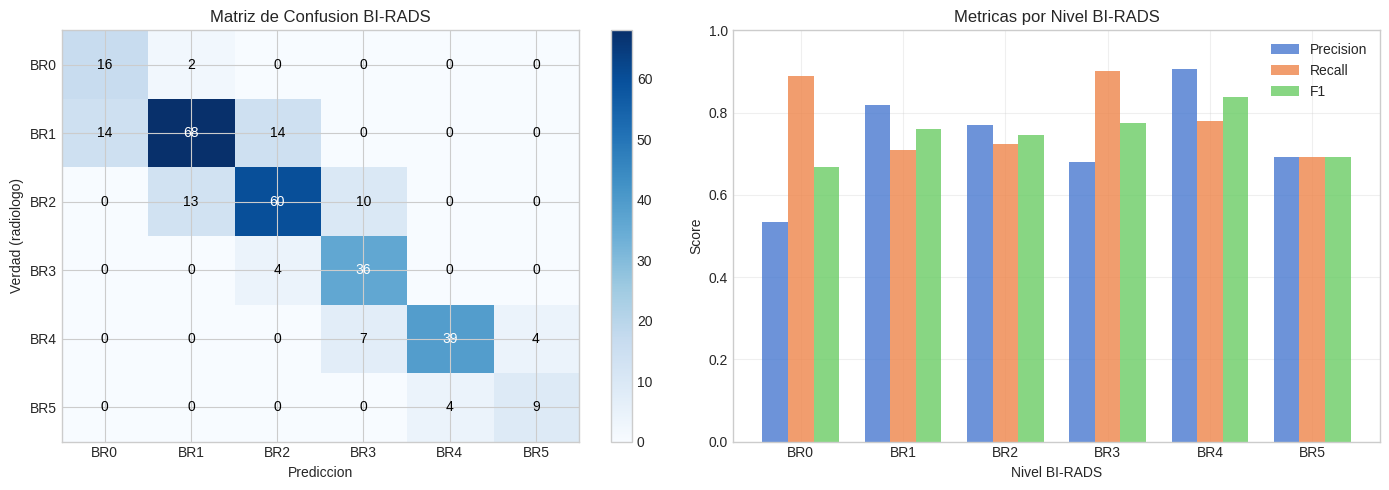

Grafica guardada: area3_confusion_matrix.png


In [75]:
## Visualizar matriz de confusion
cm = np.array(medical_report['area_3_medical_metrics']['multiclass_classification']['confusion_matrix'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

## Matriz de confusion multiclase
im = axes[0].imshow(cm, cmap='Blues', aspect='auto')
axes[0].set_xticks(range(6))
axes[0].set_yticks(range(6))
axes[0].set_xticklabels([f'BR{i}' for i in range(6)])
axes[0].set_yticklabels([f'BR{i}' for i in range(6)])
axes[0].set_xlabel('Prediccion')
axes[0].set_ylabel('Verdad (radiologo)')
axes[0].set_title('Matriz de Confusion BI-RADS')
for i in range(6):
    for j in range(6):
        axes[0].text(j, i, str(cm[i, j]), ha='center', va='center',
                     color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.colorbar(im, ax=axes[0])

## Metricas por clase
per_class = medical_report['area_3_medical_metrics']['multiclass_classification']['per_class']
classes = [f'BR{i}' for i in range(6)]
f1_scores = [per_class[f'birads_{i}']['f1'] for i in range(6)]
recalls = [per_class[f'birads_{i}']['recall'] for i in range(6)]
precisions = [per_class[f'birads_{i}']['precision'] for i in range(6)]

x = np.arange(6)
width = 0.25
axes[1].bar(x - width, precisions, width, label='Precision', alpha=0.8)
axes[1].bar(x, recalls, width, label='Recall', alpha=0.8)
axes[1].bar(x + width, f1_scores, width, label='F1', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(classes)
axes[1].set_xlabel('Nivel BI-RADS')
axes[1].set_ylabel('Score')
axes[1].set_title('Metricas por Nivel BI-RADS')
axes[1].legend()
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'area3_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafica guardada: area3_confusion_matrix.png')

<h3>6.4 Curva de severidad clinica</h3>

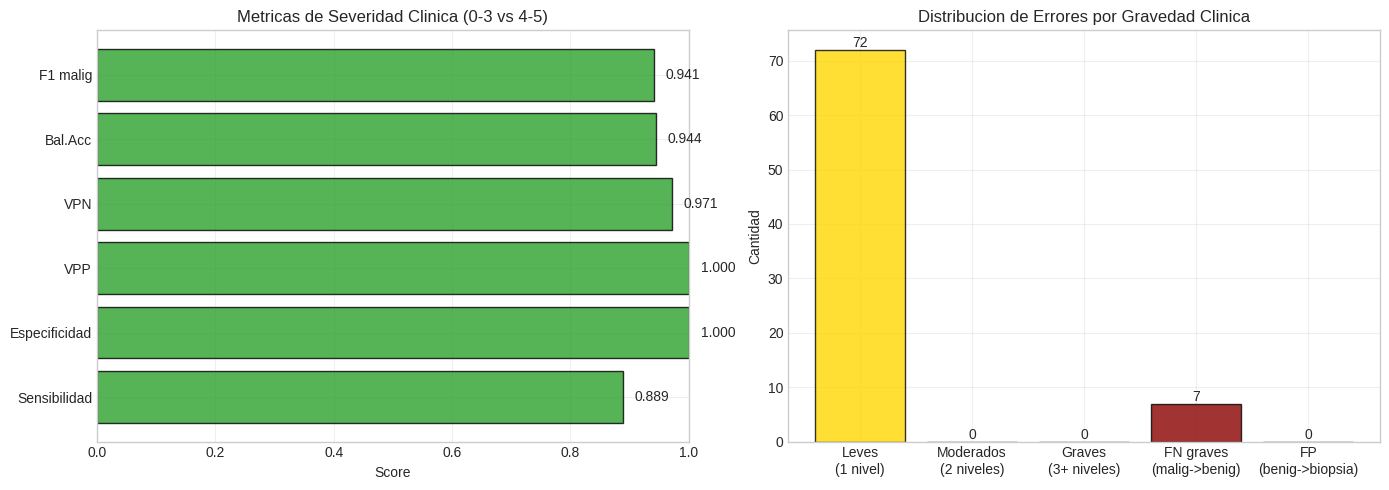

Grafica guardada: area3_clinical_severity.png


In [76]:
## Visualizar metricas de severidad clinica y analisis de errores
sev = medical_report['area_3_medical_metrics']['clinical_severity']
err = medical_report['area_3_medical_metrics']['error_analysis']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

## Metricas clinicas binarias
metric_names = ['Sensibilidad', 'Especificidad', 'VPP', 'VPN', 'Bal.Acc', 'F1 malig']
metric_vals = [sev['sensitivity'], sev['specificity'], sev['ppv'],
               sev['npv'], sev['balanced_accuracy'], sev['f1_malignant']]
colors = ['#2ca02c' if v >= 0.8 else '#ff7f0e' if v >= 0.6 else '#d62728'
          for v in metric_vals]
axes[0].barh(metric_names, metric_vals, color=colors, alpha=0.8, edgecolor='black')
axes[0].set_xlim(0, 1)
axes[0].set_xlabel('Score')
axes[0].set_title('Metricas de Severidad Clinica (0-3 vs 4-5)')
for i, v in enumerate(metric_vals):
    axes[0].text(v + 0.02, i, f'{v:.3f}', va='center')
axes[0].grid(True, alpha=0.3)

## Distribucion de errores por gravedad
error_types = ['Leves\n(1 nivel)', 'Moderados\n(2 niveles)', 'Graves\n(3+ niveles)',
               'FN graves\n(malig->benig)', 'FP\n(benig->biopsia)']
error_counts = [err['mild_errors'], err['moderate_errors'], err['severe_errors'],
                err['dangerous_false_negatives'], err['false_positives_biopsy']]
error_colors = ['#ffd700', '#ff8c00', '#dc143c', '#8b0000', '#4169e1']
axes[1].bar(error_types, error_counts, color=error_colors, alpha=0.8, edgecolor='black')
axes[1].set_ylabel('Cantidad')
axes[1].set_title('Distribucion de Errores por Gravedad Clinica')
for i, v in enumerate(error_counts):
    axes[1].text(i, v + 0.5, str(v), ha='center')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'area3_clinical_severity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafica guardada: area3_clinical_severity.png')

<h2 id='area4'>7. Area 4: Evaluacion de Hallazgos</h2>
<p>Compara los hallazgos predichos por el modelo contra los hallazgos reales descritos por el radiologo en los reportes de CDD-CESM. Es el unico dataset con reportes radiologicos, lo que permite validar la capacidad del modelo de identificar hallazgos especificos.</p>

<h3>7.1 Parser de reportes CDD-CESM</h3>

In [77]:
## El parser extrae hallazgos estructurados del texto libre de los reportes
## usando el lexico BI-RADS. Mapea descripciones a slots del esquema.
parser = ReportFindingsParser()

print_section('PARSER DE REPORTES CDD-CESM', width=70)
print(f'Terminos de busqueda cargados: {len(parser.search_terms)}')
print()

## Probar con textos de ejemplo tipo CDD-CESM (campo Findings)
ejemplos = [
    'There is a spiculated mass with irregular shape and associated fine pleomorphic calcifications in grouped distribution. High density lesion.',
    'Oval circumscribed mass with low density. Round calcifications scattered. No suspicious findings.',
    'Architectural distortion with focal asymmetry. Amorphous calcifications segmental distribution.',
]

for i, texto in enumerate(ejemplos, 1):
    parsed = parser.parse(texto)
    print(f'Ejemplo {i}:')
    print(f'  Texto: "{texto[:65]}..."')
    print(f'  Hallazgos extraidos:')
    for slot, val in parsed.items():
        print(f'    {slot:28s} -> {val}')
    print()

                     PARSER DE REPORTES CDD-CESM                      
Terminos de busqueda cargados: 106

Ejemplo 1:
  Texto: "There is a spiculated mass with irregular shape and associated fi..."
  Hallazgos extraidos:
    calc_morphology              -> fine pleomorphic
    mass_density                 -> high density
    mass_margin                  -> spiculated
    mass_shape                   -> irregular
    calc_distribution            -> grouped

Ejemplo 2:
  Texto: "Oval circumscribed mass with low density. Round calcifications sc..."
  Hallazgos extraidos:
    calc_morphology              -> round calcifications
    mass_margin                  -> circumscribed
    mass_density                 -> low density
    calc_distribution            -> diffuse
    breast_density               -> scattered fibroglandular
    mass_shape                   -> round

Ejemplo 3:
  Texto: "Architectural distortion with focal asymmetry. Amorphous calcific..."
  Hallazgos extraidos:
    calc

<h3>7.2 Procesamiento de filas CDD-CESM</h3>

In [78]:
## Simular el procesamiento de filas del CSV/XLSX de CDD-CESM
## En la fase de entrenamiento, estas filas vendran del archivo real
## CDD-CESM-Annotations-June2022.csv con columnas:
##   Findings, ACR_BIRADS, Breast_Density, Patient_ID, Side, View

filas_demo = [
    {
        'Findings': 'Spiculated mass with irregular margins, high density. Architectural distortion present.',
        'ACR_BIRADS': 'BIRADS 5',
        'Breast_Density': 'C',
    },
    {
        'Findings': 'Oval mass with circumscribed margins, low density. Benign appearance.',
        'ACR_BIRADS': 'BIRADS 2',
        'Breast_Density': 'B',
    },
    {
        'Findings': 'Fine pleomorphic calcifications in segmental distribution.',
        'ACR_BIRADS': 'BIRADS 4',
        'Breast_Density': 'D',
    },
]

print_section('PROCESAMIENTO DE FILAS CDD-CESM', width=70)
for i, fila in enumerate(filas_demo, 1):
    result = parse_cddcesm_row(fila, parser)
    print(f'Fila {i}:')
    print(f'  BI-RADS: {result["birads"]}')
    print(f'  Hallazgos estructurados:')
    for slot, val in result['findings'].items():
        print(f'    {slot:28s} -> {val}')
    print()

                   PROCESAMIENTO DE FILAS CDD-CESM                    
Fila 1:
  BI-RADS: 5
  Hallazgos estructurados:
    architectural_distortion     -> architectural distortion
    mass_density                 -> high density
    mass_margin                  -> spiculated
    mass_shape                   -> irregular
    breast_density               -> heterogeneously dense

Fila 2:
  BI-RADS: 2
  Hallazgos estructurados:
    mass_margin                  -> circumscribed
    mass_density                 -> low density
    mass_shape                   -> oval
    breast_density               -> scattered fibroglandular

Fila 3:
  BI-RADS: 4
  Hallazgos estructurados:
    calc_morphology              -> fine pleomorphic
    calc_distribution            -> segmental
    breast_density               -> extremely dense



<h3>7.3 Evaluacion modelo vs reportes reales</h3>

In [79]:
## Comparar hallazgos predichos por el modelo contra los reportes reales
## NOTA: con el modelo entrenado, las predicciones vendran de model.predict()
## sobre las imagenes de CDD-CESM. Aqui simulamos para validar el pipeline.

evaluator = FindingsEvaluationReport()

## Ground truth: hallazgos extraidos de los reportes CDD-CESM
ground_truths = []
for fila in filas_demo:
    result = parse_cddcesm_row(fila, parser)
    ground_truths.append(result['findings'])

## Predicciones simuladas del modelo (con algunos errores para demostracion)
predictions = [
    ## Caso 1: prediccion casi perfecta
    {'mass_margin': 'spiculated', 'mass_shape': 'irregular', 'mass_density': 'high density',
     'architectural_distortion': 'architectural distortion', 'breast_density': 'heterogeneously dense'},
    ## Caso 2: confunde la forma (round en vez de oval)
    {'mass_margin': 'circumscribed', 'mass_shape': 'round', 'mass_density': 'low density',
     'breast_density': 'scattered fibroglandular'},
    ## Caso 3: detecta calcificaciones pero confunde morfologia
    {'calc_morphology': 'amorphous', 'calc_distribution': 'segmental',
     'breast_density': 'extremely dense'},
]

## Evaluar
findings_report = evaluator.evaluate_batch(predictions, ground_truths)
print(evaluator.generate_summary(findings_report))

## Guardar reporte
findings_path = RESULTS_DIR / f'area4_findings_eval_{get_timestamp()}.json'
save_json(findings_report, findings_path)
print(f'Reporte guardado: {findings_path.name}')

AREA 4: EVALUACION DE HALLAZGOS

Casos evaluados: 3

METRICAS GLOBALES
----------------------------------------------------------------------
  Macro F1:               0.8750
  Macro Precision:        0.8750
  Macro Recall:           0.8750
  Micro F1:               1.0000
  Exact Match (promedio): 0.9167

METRICAS POR SLOT DE HALLAZGO
----------------------------------------------------------------------
  Slot                             F1   Prec    Rec  Exact
  --------------------------------------------------------
  breast_density                1.000  1.000  1.000  1.000
  mass_shape                    1.000  1.000  1.000  0.667
  mass_margin                   1.000  1.000  1.000  1.000
  mass_density                  1.000  1.000  1.000  1.000
  calc_morphology               1.000  1.000  1.000  0.667
  calc_distribution             1.000  1.000  1.000  1.000
  asymmetry                     0.000  0.000  0.000  1.000
  architectural_distortion      1.000  1.000  1.000  1.000



<h3>7.4 Visualizacion de concordancia de hallazgos</h3>

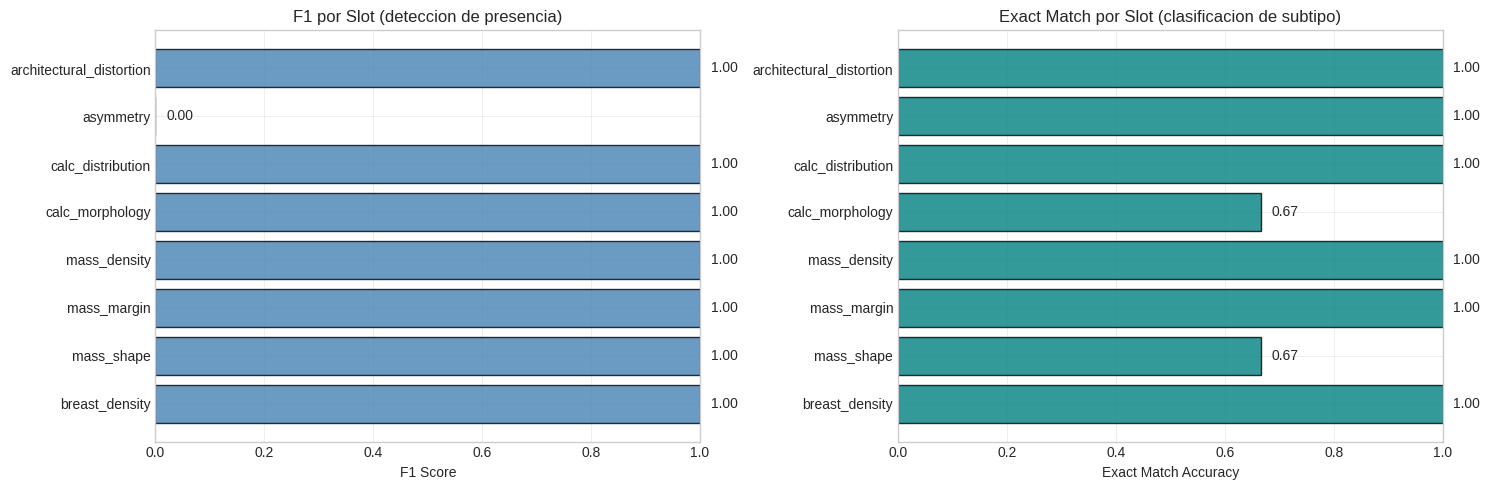

Grafica guardada: area4_findings_concordance.png

Resumen global:
  Macro F1 (deteccion): 0.8750
  Exact Match (subtipo): 0.9167


In [80]:
## Visualizar metricas por slot de hallazgo
m = findings_report['area_4_findings_evaluation']
per_slot = m['per_slot']

slot_names = list(per_slot.keys())
f1_scores = [per_slot[s]['f1'] for s in slot_names]
exact_scores = [per_slot[s]['exact_match_accuracy'] for s in slot_names]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

## F1 por slot (deteccion de presencia)
y_pos = np.arange(len(slot_names))
axes[0].barh(y_pos, f1_scores, color='steelblue', alpha=0.8, edgecolor='black')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(slot_names)
axes[0].set_xlabel('F1 Score')
axes[0].set_title('F1 por Slot (deteccion de presencia)')
axes[0].set_xlim(0, 1)
for i, v in enumerate(f1_scores):
    axes[0].text(v + 0.02, i, f'{v:.2f}', va='center')
axes[0].grid(True, alpha=0.3)

## Exact match por slot (clasificacion del subtipo)
axes[1].barh(y_pos, exact_scores, color='teal', alpha=0.8, edgecolor='black')
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(slot_names)
axes[1].set_xlabel('Exact Match Accuracy')
axes[1].set_title('Exact Match por Slot (clasificacion de subtipo)')
axes[1].set_xlim(0, 1)
for i, v in enumerate(exact_scores):
    axes[1].text(v + 0.02, i, f'{v:.2f}', va='center')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'area4_findings_concordance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafica guardada: area4_findings_concordance.png')
print()
print(f'Resumen global:')
print(f'  Macro F1 (deteccion): {m["macro_f1"]:.4f}')
print(f'  Exact Match (subtipo): {m["mean_exact_match"]:.4f}')

<hr/>
<h2 id='datasets'>8. Validacion de los 5 Datasets</h2>
<p>Antes del entrenamiento, se valida la estructura, integridad y consistencia de los 5 datasets contra las especificaciones oficiales de cada fuente. Los validadores verifican archivos requeridos, columnas, rangos de etiquetas (BI-RADS, densidad), conteo de imagenes y distribuciones de clases.</p>
<table>
<tr><th>Dataset</th><th>Fuente</th><th>Anotaciones</th><th>Reportes</th></tr>
<tr><td>VinDr-Mammo</td><td>PhysioNet</td><td>breast-level + finding (BI-RADS 1-5)</td><td>No</td></tr>
<tr><td>CDD-CESM</td><td>TCIA</td><td>XLSX (BI-RADS 1-6, Findings)</td><td>Si</td></tr>
<tr><td>CBIS-DDSM</td><td>TCIA</td><td>mass/calc CSVs (assessment, pathology)</td><td>No</td></tr>
<tr><td>DMID</td><td>FigShare</td><td>CSV (class B/M/N, tissue)</td><td>Si</td></tr>
<tr><td>INbreast</td><td>Academic Radiology</td><td>CSV (Bi-Rads, ACR)</td><td>Si</td></tr>
</table>

<h3>8.1 Ejecucion de validadores</h3>

In [81]:
## Importar el paquete de validadores
## Estructura: Tesis/data_validators/ con _base.py, run_all.py y los 5 validate_*.py
sys.path.insert(0, str(PROJECT_ROOT))
from data_validators import run_all

## Rutas reales de los 5 datasets en el H200
DATASET_ROOTS = {
    'vindr_mammo': str(DATA_DIR / 'vindr-mammo'),
    'inbreast':    str(DATA_DIR / 'inbreast'),
    'dmid':        str(DATA_DIR / 'dmid'),
    'cdd_cesm':    str(DATA_DIR / 'cdd-cesm'),
    'cbis_ddsm':   str(DATA_DIR / 'cbis-ddsm'),
}

print_section('VALIDACION DE LOS 5 DATASETS', width=70)
print()

## Ejecutar todos los validadores
validation_result = run_all.run_all(DATASET_ROOTS, verbose=True)

print()
resumen = validation_result['resumen']
print('RESUMEN GLOBAL:')
print(f'  Datasets validados:  {resumen["total_datasets"]}')
print(f'  OK:                  {resumen["OK"]}')
print(f'  WARNING:             {resumen["WARNING"]}')
print(f'  ERROR:               {resumen["ERROR"]}')
print(f'  Total imagenes:      {resumen["total_imagenes"]:,}')
print(f'  Total casos:         {resumen["total_casos"]:,}')
print(f'  Tiempo total:        {validation_result["tiempo_total_s"]}s')

                     VALIDACION DE LOS 5 DATASETS                     

  Validando VinDr-Mammo... WARNING  (0 errores, 2 warnings, 0.2s)
  Validando INbreast... OK  (0 errores, 0 warnings, 0.0s)
  Validando DMID... OK  (0 errores, 0 warnings, 0.0s)
  Validando CDD-CESM... OK  (0 errores, 0 warnings, 0.1s)
  Validando CBIS-DDSM... WARNING  (0 errores, 2 warnings, 0.1s)

RESUMEN GLOBAL:
  Datasets validados:  5
  OK:                  3
  ERROR:               0
  Total imagenes:      29,733
  Total casos:         26,631
  Tiempo total:        0.47s


<h3>8.2 Detalle por dataset</h3>

In [82]:
## Mostrar detalle de cada dataset validado
for nombre, res in validation_result['resultados'].items():
    print_section(f'{nombre} - Estado: {res["estado"]}', width=70)

    ## Metricas escalares
    m = res['metricas']
    print(f'  Imagenes:   {m.get("n_imagenes", 0):,}')
    print(f'  Casos:      {m.get("n_casos", 0):,}')
    print(f'  Pacientes:  {m.get("n_pacientes", 0):,}')

    ## Issues y warnings
    if res['issues']:
        print(f'  ERRORES ({len(res["issues"])}):')
        for iss in res['issues']:
            print(f'    - {iss}')
    if res['warnings']:
        print(f'  WARNINGS ({len(res["warnings"])}):')
        for wrn in res['warnings']:
            print(f'    - {wrn}')

    ## Distribucion BI-RADS si existe
    birads_dist = res['distribuciones'].get('birads', {})
    if birads_dist:
        print(f'  Distribucion BI-RADS: {birads_dist}')

    print()

                    VinDr-Mammo - Estado: WARNING                     
  Imagenes:   20,000
  Casos:      20,000
  Pacientes:  5,000
  WARNINGS (2):
    - finding_annotations: 19 bboxes con xmin negativo
    - finding_annotations: 3 bboxes con ymin negativo

                        INbreast - Estado: OK                         
  Imagenes:   410
  Casos:      410
  Pacientes:  410
  Distribucion BI-RADS: {1: 67, 2: 220, 3: 23, 5: 49, 6: 8}

                          DMID - Estado: OK                           
  Imagenes:   1,049
  Casos:      647
  Pacientes:  0

                        CDD-CESM - Estado: OK                         
  Imagenes:   2,006
  Casos:      2,006
  Pacientes:  326
  Distribucion BI-RADS: {1: 801, 2: 325, 3: 156, 4: 295, 5: 340, 6: 8}

                     CBIS-DDSM - Estado: WARNING                      
  Imagenes:   6,268
  Casos:      3,568
  Pacientes:  691
  WARNINGS (2):
    - mass_train: 2 filas con subtlety=0 (anomalia del dataset original, no error d

<h3>8.3 Dashboard visual de validacion</h3>

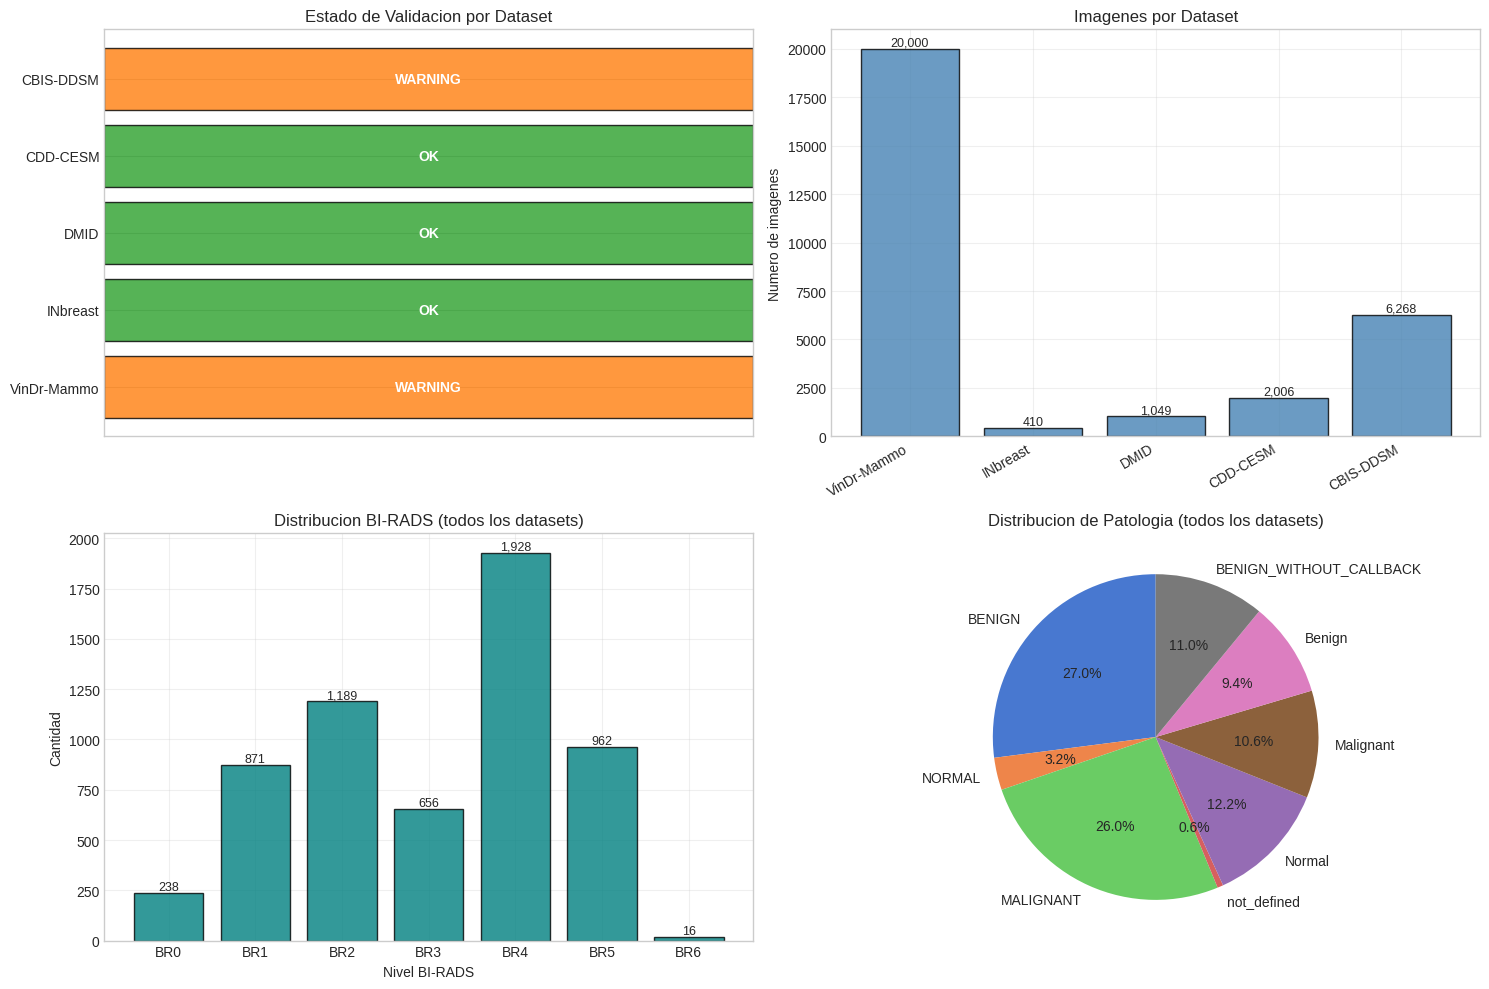

Dashboard guardado: datasets_validation_dashboard.png
Reporte de validacion guardado: datasets_validation_2026-06-02_00-47-27.json


In [83]:
## Dashboard visual: estado y distribuciones de los datasets
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

## 1. Estado de cada dataset
nombres = list(validation_result['resultados'].keys())
estados = [validation_result['resultados'][n]['estado'] for n in nombres]
estado_color = {'OK': '#2ca02c', 'WARNING': '#ff7f0e', 'ERROR': '#d62728'}
colores = [estado_color.get(e, '#888888') for e in estados]

axes[0, 0].barh(nombres, [1]*len(nombres), color=colores, alpha=0.8, edgecolor='black')
axes[0, 0].set_xlim(0, 1)
axes[0, 0].set_xticks([])
axes[0, 0].set_title('Estado de Validacion por Dataset')
for i, (n, e) in enumerate(zip(nombres, estados)):
    axes[0, 0].text(0.5, i, e, ha='center', va='center', fontweight='bold', color='white')

## 2. Numero de imagenes por dataset
n_imagenes = [validation_result['resultados'][n]['metricas'].get('n_imagenes', 0) for n in nombres]
axes[0, 1].bar(range(len(nombres)), n_imagenes, color='steelblue', alpha=0.8, edgecolor='black')
axes[0, 1].set_xticks(range(len(nombres)))
axes[0, 1].set_xticklabels(nombres, rotation=30, ha='right')
axes[0, 1].set_ylabel('Numero de imagenes')
axes[0, 1].set_title('Imagenes por Dataset')
for i, v in enumerate(n_imagenes):
    axes[0, 1].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)
axes[0, 1].grid(True, alpha=0.3)

## 3. Distribucion BI-RADS agregada de todos los datasets
birads_total = {}
for n in nombres:
    for k, v in validation_result['resultados'][n]['distribuciones'].get('birads', {}).items():
        birads_total[k] = birads_total.get(k, 0) + v
if birads_total:
    keys = sorted(birads_total.keys())
    vals = [birads_total[k] for k in keys]
    axes[1, 0].bar([f'BR{k}' for k in keys], vals, color='teal', alpha=0.8, edgecolor='black')
    axes[1, 0].set_xlabel('Nivel BI-RADS')
    axes[1, 0].set_ylabel('Cantidad')
    axes[1, 0].set_title('Distribucion BI-RADS (todos los datasets)')
    for i, v in enumerate(vals):
        axes[1, 0].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)
    axes[1, 0].grid(True, alpha=0.3)
else:
    axes[1, 0].text(0.5, 0.5, 'Sin datos BI-RADS', ha='center', va='center')
    axes[1, 0].axis('off')

## 4. Distribucion de patologia agregada
patologia_total = {}
for n in nombres:
    for k, v in validation_result['resultados'][n]['distribuciones'].get('patologia', {}).items():
        patologia_total[k] = patologia_total.get(k, 0) + v
if patologia_total:
    labels = list(patologia_total.keys())
    sizes = list(patologia_total.values())
    axes[1, 1].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[1, 1].set_title('Distribucion de Patologia (todos los datasets)')
else:
    axes[1, 1].text(0.5, 0.5, 'Sin datos de patologia', ha='center', va='center')
    axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'datasets_validation_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard guardado: datasets_validation_dashboard.png')

## Guardar reporte de validacion
val_path = RESULTS_DIR / f'datasets_validation_{get_timestamp()}.json'
save_json(validation_result, val_path)
print(f'Reporte de validacion guardado: {val_path.name}')

<h3>8.4 Estandarizacion BI-RADS (remapeo 6 a 5)</h3>
<p>El sistema ACR BI-RADS define categorias 0-6, pero la categoria 6 indica malignidad confirmada por biopsia previa, que depende de informacion histopatologica externa y no de los hallazgos de la imagen. Dado que el modelo clasifica a partir de la imagen, se remapea BI-RADS 6 a BI-RADS 5 (altamente sugestivo de malignidad), estandarizando todos los datasets al rango 0-5.</p>

In [84]:
## Estandarizacion de niveles BI-RADS al rango 0-5
print_section('ESTANDARIZACION BI-RADS (0-5)', width=70)
print()
print(get_clinical_explanation())
print()

## Aplicar remapeo a las distribuciones reales de cada dataset validado
print_section('REMAPEO POR DATASET', width=70)
print()

birads_antes = {}
birads_despues = {}

for nombre, res in validation_result['resultados'].items():
    birads_dist = res['distribuciones'].get('birads', {})
    if not birads_dist:
        continue

    ## Reconstruir lista de valores desde la distribucion
    valores = []
    for nivel, count in birads_dist.items():
        valores.extend([int(nivel)] * count)

    ## Normalizar
    normalizados, reporte = normalize_birads_list(valores)

    ## Mostrar remapeo si hubo cambios
    if reporte['remapped_count'] > 0:
        print(generate_remap_summary(reporte, nombre))

    ## Acumular distribuciones antes y despues
    from collections import Counter
    dist_antes = dict(sorted(Counter(valores).items()))
    dist_despues = dict(sorted(Counter(normalizados).items()))
    birads_antes[nombre] = dist_antes
    birads_despues[nombre] = dist_despues

print()
print_section('DISTRIBUCION BI-RADS ANTES Y DESPUES', width=70)
for nombre in birads_antes:
    print(f'{nombre}:')
    print(f'  Antes:   {birads_antes[nombre]}')
    print(f'  Despues: {birads_despues[nombre]}')
    print()

                    ESTANDARIZACION BI-RADS (0-5)                     

ESTANDARIZACION BI-RADS (0-5):
El sistema ACR BI-RADS define categorias 0-6. La categoria 6 indica 'malignidad conocida comprobada por biopsia', que depende de un diagnostico histopatologico previo y no de los hallazgos radiologicos de la imagen. Dado que el modelo clasifica a partir de la imagen, BI-RADS 6 se remapea a BI-RADS 5 (altamente sugestivo de malignidad), agrupando ambos en el extremo maligno. El modelo predice el rango estandar 0-5 conforme a la practica de clasificacion por imagen.

                         REMAPEO POR DATASET                          

[INbreast] 8 de 367 valores remapeados:
[INbreast]   BI-RADS 6 -> BI-RADS 5: 8 casos
[CDD-CESM] 8 de 1925 valores remapeados:
[CDD-CESM]   BI-RADS 6 -> BI-RADS 5: 8 casos

                 DISTRIBUCION BI-RADS ANTES Y DESPUES                 
INbreast:
  Antes:   {1: 67, 2: 220, 3: 23, 5: 49, 6: 8}
  Despues: {1: 67, 2: 220, 3: 23, 5: 57}

CDD-CESM:
  A

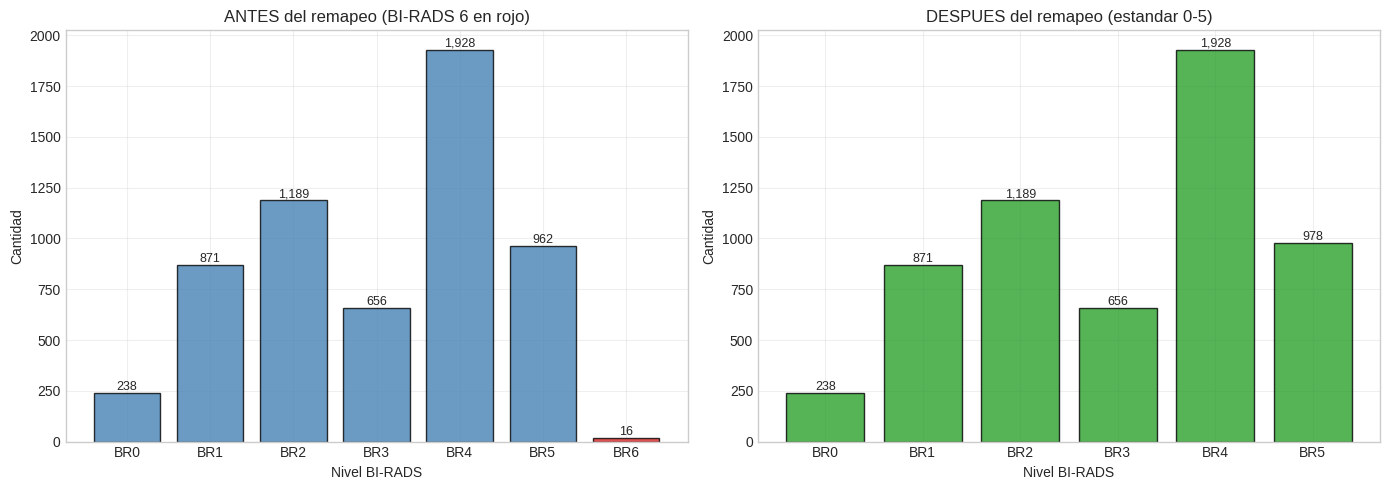

Grafica guardada: birads_standardization.png

BI-RADS 6 eliminados: 16 casos remapeados a BI-RADS 5
Rango final: 0-5 (estandar de clasificacion por imagen)


In [85]:
## Visualizar el efecto de la estandarizacion BI-RADS
## Comparar distribucion agregada antes vs despues del remapeo

## Agregar todas las distribuciones
agg_antes = {}
agg_despues = {}
for nombre in birads_antes:
    for k, v in birads_antes[nombre].items():
        agg_antes[k] = agg_antes.get(k, 0) + v
    for k, v in birads_despues[nombre].items():
        agg_despues[k] = agg_despues.get(k, 0) + v

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

## Antes del remapeo (incluye BI-RADS 6)
niveles_antes = sorted(agg_antes.keys())
vals_antes = [agg_antes[n] for n in niveles_antes]
colores_antes = ['#d62728' if n == 6 else 'steelblue' for n in niveles_antes]
axes[0].bar([f'BR{n}' for n in niveles_antes], vals_antes,
            color=colores_antes, alpha=0.8, edgecolor='black')
axes[0].set_xlabel('Nivel BI-RADS')
axes[0].set_ylabel('Cantidad')
axes[0].set_title('ANTES del remapeo (BI-RADS 6 en rojo)')
for i, v in enumerate(vals_antes):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)
axes[0].grid(True, alpha=0.3)

## Despues del remapeo (solo 0-5)
niveles_despues = sorted(agg_despues.keys())
vals_despues = [agg_despues[n] for n in niveles_despues]
axes[1].bar([f'BR{n}' for n in niveles_despues], vals_despues,
            color='#2ca02c', alpha=0.8, edgecolor='black')
axes[1].set_xlabel('Nivel BI-RADS')
axes[1].set_ylabel('Cantidad')
axes[1].set_title('DESPUES del remapeo (estandar 0-5)')
for i, v in enumerate(vals_despues):
    axes[1].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'birads_standardization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafica guardada: birads_standardization.png')
print()
print(f'BI-RADS 6 eliminados: {agg_antes.get(6, 0)} casos remapeados a BI-RADS 5')
print(f'Rango final: 0-5 (estandar de clasificacion por imagen)')